In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

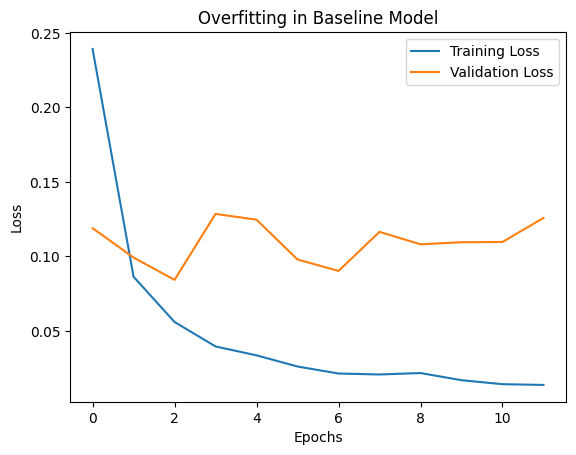

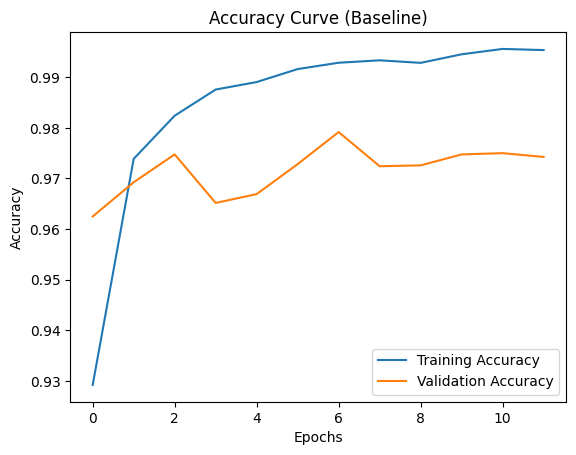

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. Flatten
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

# 4. Baseline MLP (NO regularization)
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(512, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# 5. Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Train (no epoch-wise output)
history = model.fit(
    x_train, y_train,
    epochs=12,
    batch_size=128,
    validation_split=0.2,
    verbose=0
)

# 7. Loss plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Overfitting in Baseline Model')
plt.show()

# 8. Accuracy plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve (Baseline)')
plt.show()


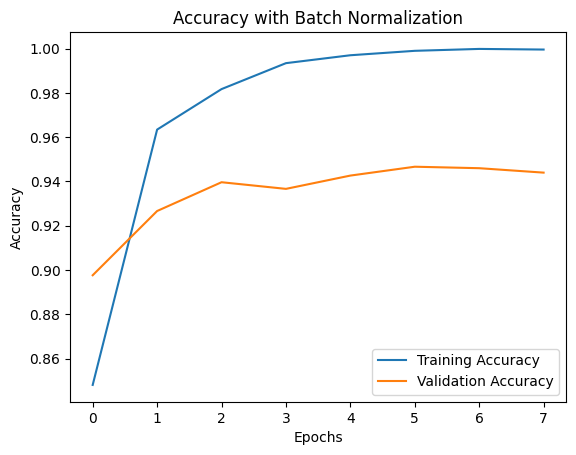

In [ ]:

# 1. Load MNIST
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

# 2. Small subset for FAST execution
x_train = x_train[:10000] / 255.0
y_train = y_train[:10000]

# 3. Flatten
x_train = x_train.reshape(-1, 28*28)

# 4. MLP with Batch Normalization
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(256, input_shape=(784,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.Dense(256),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

# 5. Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# 6. Train silently
history = model.fit(
    x_train, y_train,
    epochs=8,
    batch_size=128,
    validation_split=0.3,
    verbose=0
)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy with Batch Normalization')
plt.show()


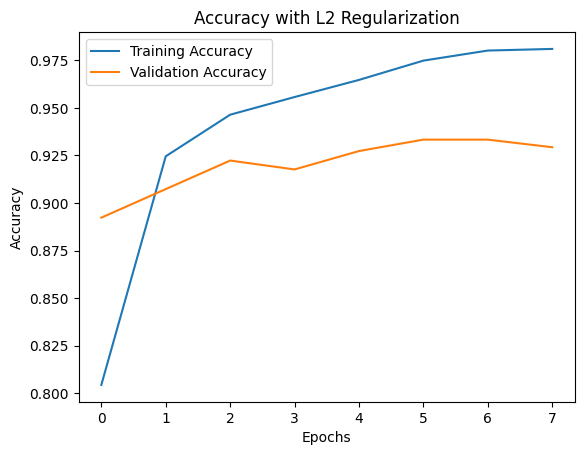

In [ ]:

# 1. Load MNIST
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

# 2. Small subset for FAST execution
x_train = x_train[:10000] / 255.0
y_train = y_train[:10000]

# 3. Flatten
x_train = x_train.reshape(-1, 28*28)

# 4. MLP with L2 Regularization
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(
        256, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.001),
        input_shape=(784,)
    ),
    tf.keras.layers.Dense(
        256, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),
    tf.keras.layers.Dense(10, activation='softmax')
])

# 5. Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# 6. Train silently
history = model.fit(
    x_train, y_train,
    epochs=8,
    batch_size=128,
    validation_split=0.3,
    verbose=0
)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy with L2 Regularization')
plt.show()


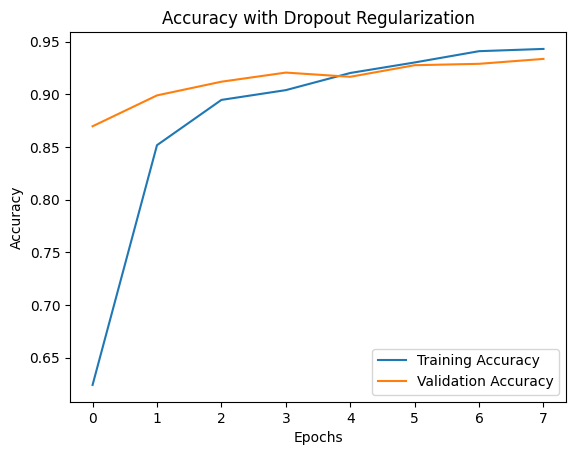

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Load MNIST
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

# 2. Small subset for FAST execution
x_train = x_train[:10000] / 255.0
y_train = y_train[:10000]

# 3. Flatten
x_train = x_train.reshape(-1, 28*28)

# 4. MLP with Dropout
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(10, activation='softmax')
])

# 5. Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# 6. Train silently
history = model.fit(
    x_train, y_train,
    epochs=8,
    batch_size=128,
    validation_split=0.3,
    verbose=0
)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy with Dropout Regularization')
plt.show()



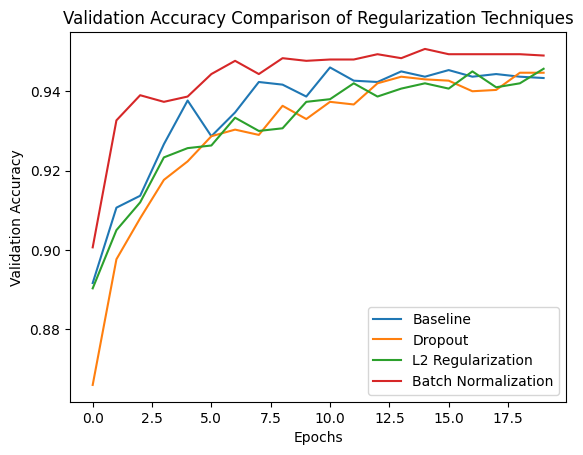

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load MNIST (small subset for fast execution)
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
x_train = x_train[:10000] / 255.0
y_train = y_train[:10000]
x_train = x_train.reshape(-1, 28*28)

EPOCHS = 20
BATCH = 128

def train_model(model):
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH,
        validation_split=0.3,
        verbose=0
    )
    return history.history['val_accuracy']

#  Baseline Model
baseline = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

#  Dropout Model
dropout = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

# L2 Regularization Model
l2_model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.001),
        input_shape=(784,)),
    tf.keras.layers.Dense(256, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Batch Normalization Model
batchnorm = tf.keras.Sequential([
    tf.keras.layers.Dense(256, input_shape=(784,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dense(256),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Train all models
acc_baseline = train_model(baseline)
acc_dropout = train_model(dropout)
acc_l2 = train_model(l2_model)
acc_bn = train_model(batchnorm)

# Combined Accuracy Plot
plt.plot(acc_baseline, label='Baseline')
plt.plot(acc_dropout, label='Dropout')
plt.plot(acc_l2, label='L2 Regularization')
plt.plot(acc_bn, label='Batch Normalization')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison of Regularization Techniques')
plt.legend()
plt.show()
